# FESOMP Plotting Tutorial

This notebook demonstrates how to visualize unstructured data using the `fesomp` plotting functions.

The key principle: **treat data as a collection of points** with coordinates. This allows the same functions to work with FESOM, ICON, MPAS, or any other unstructured model.

## 1. Setup

Load a mesh and create some sample data to plot.

In [1]:
import numpy as np
import fesomp

# Load mesh
mesh = fesomp.load_mesh("../tests/data/pi-mesh/fesom.mesh.diag.nc")
print(f"Mesh: {mesh.n2d} nodes, {mesh.nelem} elements")

# Use bottom depth as sample data
data = mesh.node_bottom_depth
print(f"Data range: {data.min():.0f} to {data.max():.0f} m")

Mesh: 3140 nodes, 5839 elements
Data range: 30 to 5650 m


## 2. Simple Plot

The simplest way to plot - just provide data and coordinates.

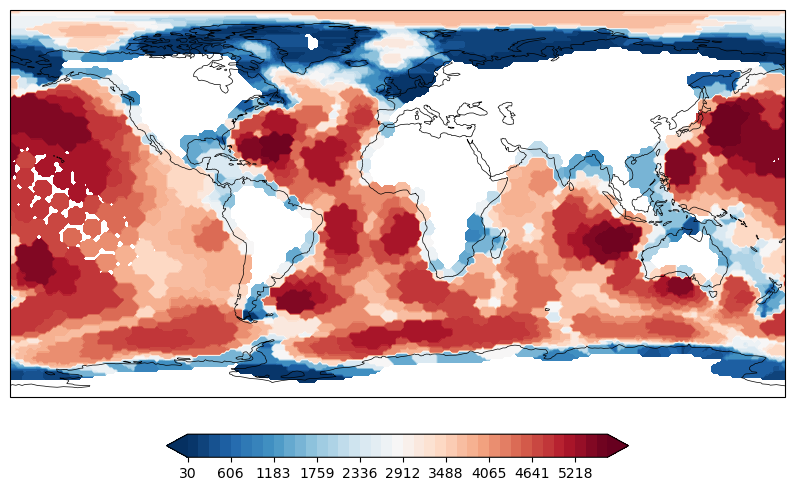

In [8]:
# Simple plot with defaults
fig, axes, interp = fesomp.plot(data, mesh.lon, mesh.lat, influence=500000)
# plt.show()

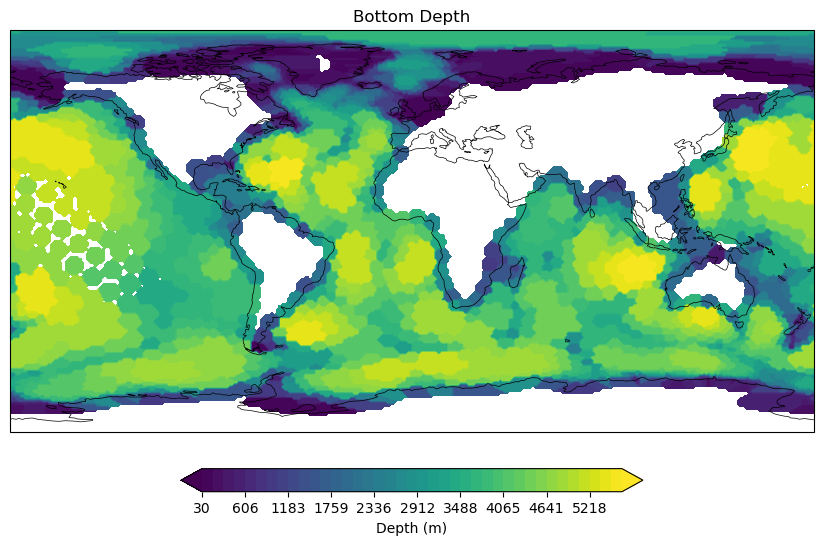

In [10]:
# Need to import plt for plt.show()
import matplotlib.pyplot as plt

# Plot with options
fig, axes, interp = fesomp.plot(
    data, mesh.lon, mesh.lat,
    influence=500000,
    cmap='viridis',
    units='Depth (m)',
    titles='Bottom Depth',
    figsize=(12, 6),
)
plt.show()

## 3. Interpolation Options

Control how data is interpolated to the regular grid.

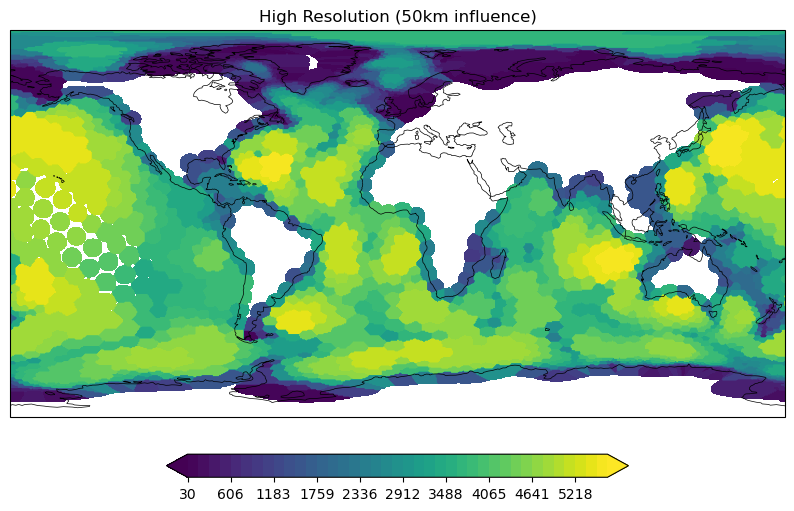

In [12]:
# Higher resolution interpolation
fig, axes, interp = fesomp.plot(
    data, mesh.lon, mesh.lat,
    res=(720, 360),  # Higher resolution grid
    influence=500000,  # 500 km influence radius
    cmap='viridis',
    titles='High Resolution (50km influence)',
)
plt.show()

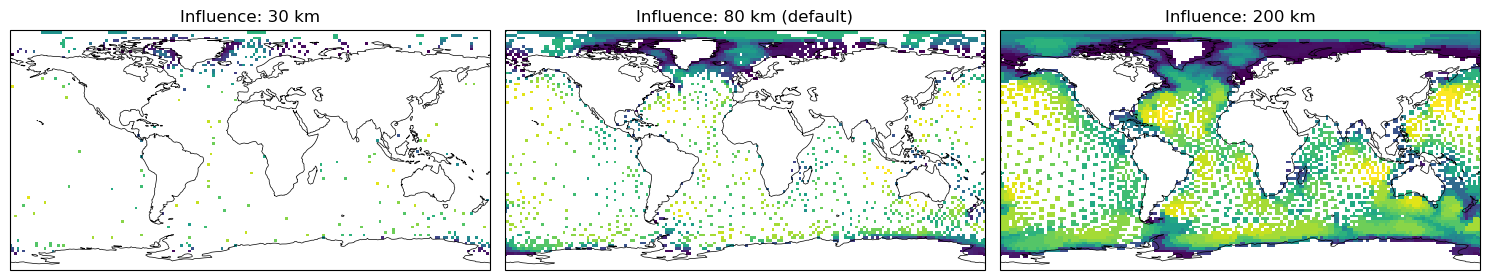

In [13]:
# Compare different influence radii
fig, axes = plt.subplots(1, 3, figsize=(15, 4), 
                          subplot_kw={'projection': __import__('cartopy').crs.PlateCarree()})

for ax, influence, title in zip(axes, [30000, 80000, 200000], 
                                 ['30 km', '80 km (default)', '200 km']):
    data_reg, lon_reg, lat_reg = fesomp.regrid(
        data, mesh.lon, mesh.lat,
        influence=influence,
        res=(180, 90)
    )
    im = ax.pcolormesh(lon_reg, lat_reg, data_reg, cmap='viridis')
    ax.coastlines(linewidth=0.5)
    ax.set_title(f'Influence: {title}')

plt.tight_layout()
plt.show()

## 4. Map Projections

Different projections for different purposes.

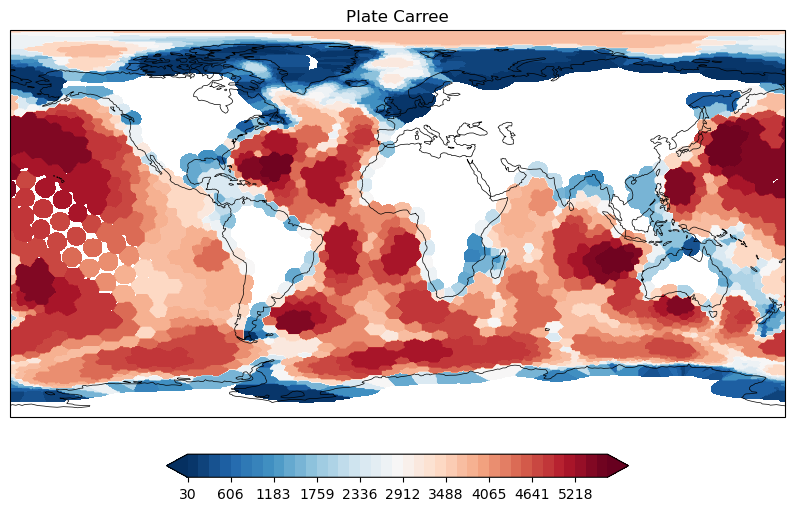

In [14]:
# Plate Carree (default)
fig, axes, _ = fesomp.plot(
    data, mesh.lon, mesh.lat,
    mapproj='pc',
    titles='Plate Carree',
    interpolator=interp,
)
plt.show()

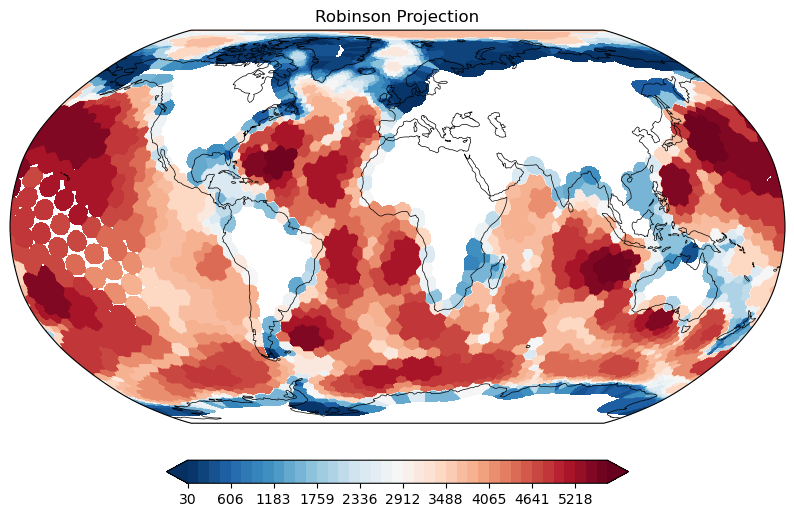

In [15]:
# Robinson projection (good for global maps)
fig, axes, _ = fesomp.plot(
    data, mesh.lon, mesh.lat,
    mapproj='rob',
    titles='Robinson Projection',
    interpolator=interp,
)
plt.show()

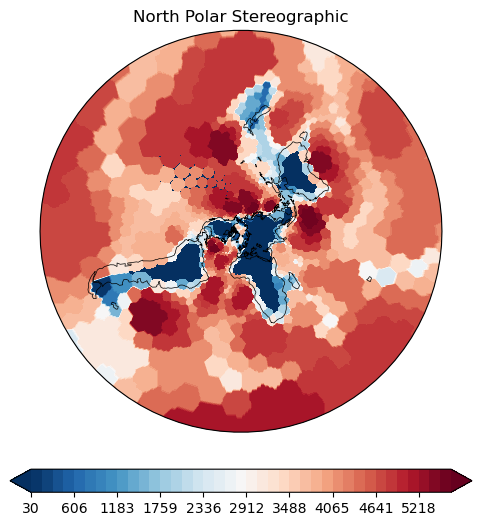

In [16]:
# North Polar Stereographic
fig, axes, _ = fesomp.plot(
    data, mesh.lon, mesh.lat,
    mapproj='np',
    titles='North Polar Stereographic',
    interpolator=interp,
)
plt.show()

## 5. Regional Plots

Zoom into specific regions using the `box` parameter.

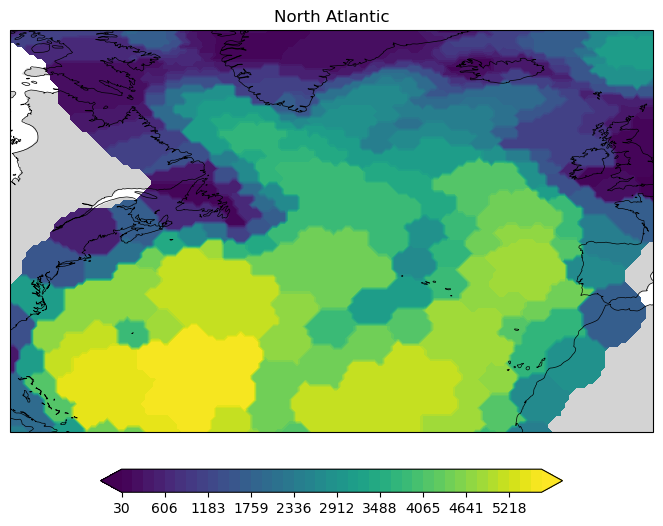

In [18]:
# North Atlantic region
fig, axes, interp_regional = fesomp.plot(
    data, mesh.lon, mesh.lat,
    box=(-80, 0, 20, 70),  # lon_min, lon_max, lat_min, lat_max
    res=(160, 100),
    influence=500000,
    cmap='viridis',
    titles='North Atlantic',
    coastlines=True,
    land=True,
)
plt.show()

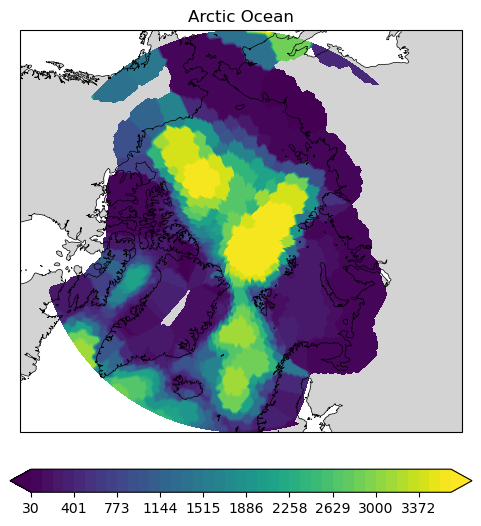

In [19]:
# Arctic region
fig, axes, _ = fesomp.plot(
    data, mesh.lon, mesh.lat,
    box=(-180, 180, 60, 90),
    mapproj='np',
    res=(360, 60),
    influence=500000,
    cmap='viridis',
    titles='Arctic Ocean',
    land=True,
)
plt.show()

## 6. Multiple Subplots

Plot multiple fields side by side using `rowscol`.

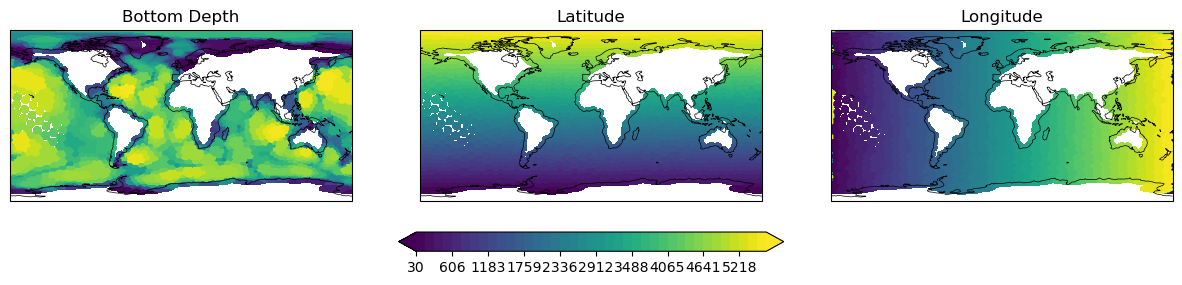

In [21]:
# Create different data fields
data_depth = mesh.node_bottom_depth
data_lat = mesh.lat
data_lon = mesh.lon

# Plot all three
fig, axes, interp = fesomp.plot(
    [data_depth, data_lat, data_lon],
    mesh.lon, mesh.lat,
    rowscol=(1, 3),
    titles=['Bottom Depth', 'Latitude', 'Longitude'],
    figsize=(15, 5),
    cmap='viridis',
    influence=500000
)
plt.show()

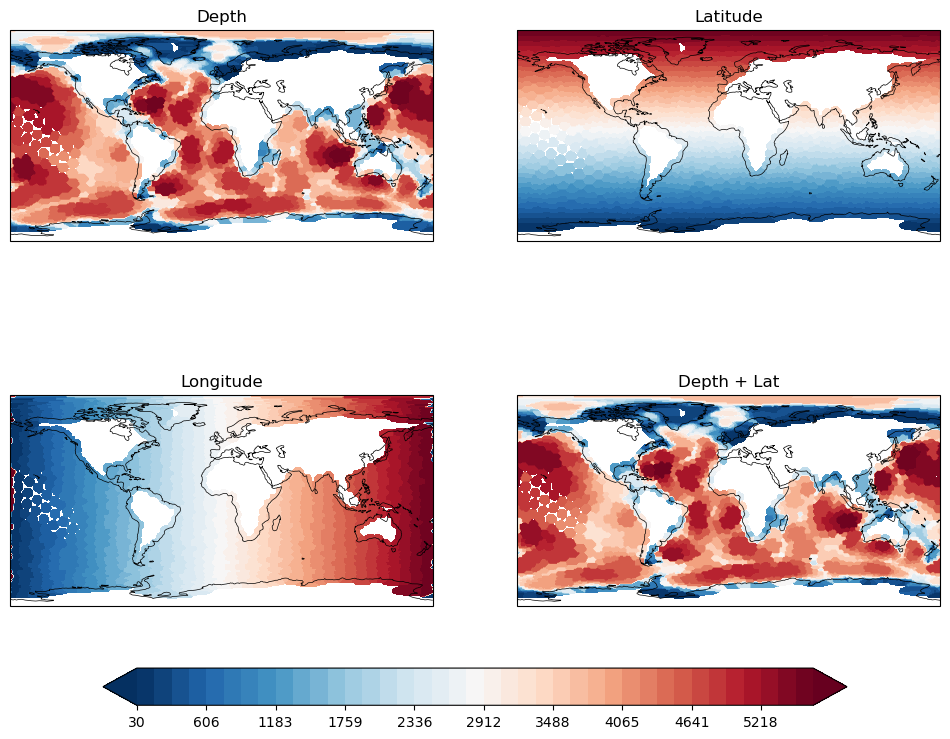

In [22]:
# 2x2 grid of plots
fig, axes, _ = fesomp.plot(
    [data_depth, data_lat, data_lon, data_depth + data_lat],
    mesh.lon, mesh.lat,
    rowscol=(2, 2),
    titles=['Depth', 'Latitude', 'Longitude', 'Depth + Lat'],
    figsize=(12, 10),
    interpolator=interp,  # Reuse cached interpolator
)
plt.show()

## 7. Caching for Performance

When plotting multiple variables, use the `RegridInterpolator` to cache the interpolation indices.

In [26]:
import time

# Create interpolator once
interp = fesomp.RegridInterpolator(
    mesh.lon, mesh.lat,
    box=(-180, 180, -90, 90),
    res=(360, 180),
    method='nn',
    influence=500000,
)
print("Interpolator created and cached")

# Time multiple interpolations
t0 = time.time()
for i in range(10):
    data_reg, _, _ = interp(mesh.node_bottom_depth)
t1 = time.time()

print(f"10 interpolations: {(t1-t0)*1000:.1f} ms ({(t1-t0)*100:.2f} ms each)")

Interpolator created and cached
10 interpolations: 3.7 ms (0.37 ms each)


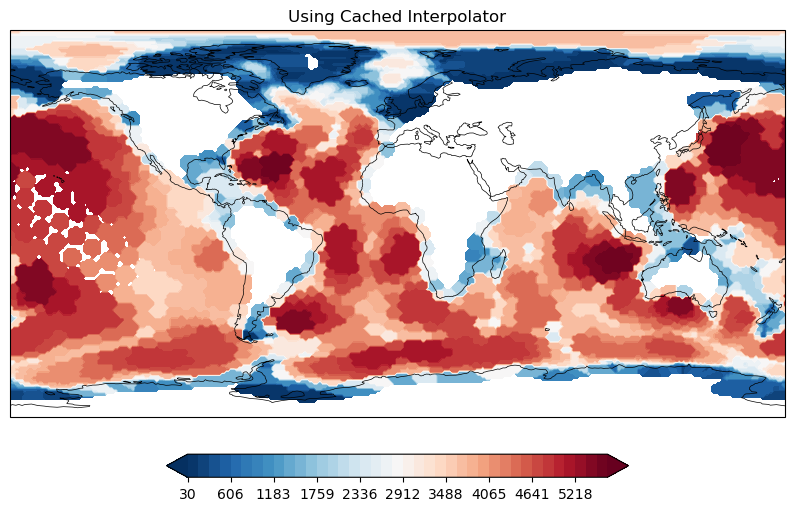

In [27]:
# Use cached interpolator with plot()
fig, axes, _ = fesomp.plot(
    data, mesh.lon, mesh.lat,
    interpolator=interp,  # Pass cached interpolator
    titles='Using Cached Interpolator',
   
)
plt.show()

## 8. Using `regrid()` Directly

For more control, use `fesomp.regrid()` to interpolate data, then plot with your own code.

In [34]:
# Regrid data to regular grid
data_reg, lon_reg, lat_reg = fesomp.regrid(
    data, mesh.lon, mesh.lat,
    box=(-180, 180, -90, 90),
    res=(360, 180),
    method='nn',
    influence=500000,
)

print(f"Regridded data shape: {data_reg.shape}")
print(f"Lon range: {lon_reg[0]:.1f} to {lon_reg[-1]:.1f}")
print(f"Lat range: {lat_reg[0]:.1f} to {lat_reg[-1]:.1f}")

Regridded data shape: (180, 360)
Lon range: -180.0 to 180.0
Lat range: -90.0 to 90.0


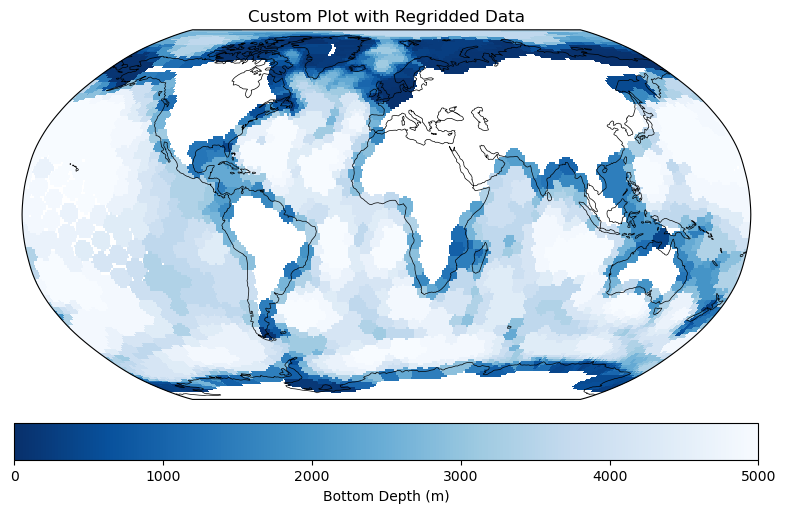

In [35]:
# Now use the regridded data with custom plotting
import cartopy.crs as ccrs

fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.Robinson()})

# Plot with custom options
im = ax.pcolormesh(
    lon_reg, lat_reg, data_reg,
    transform=ccrs.PlateCarree(),
    cmap='Blues_r',  # cmocean colormap if available
    vmin=0, vmax=5000,
)

ax.coastlines(linewidth=0.5)
ax.set_global()
plt.colorbar(im, ax=ax, label='Bottom Depth (m)', orientation='horizontal', 
             pad=0.05, shrink=0.8)
ax.set_title('Custom Plot with Regridded Data')
plt.show()

## 9. Plot Types

Choose between contourf and pcolormesh.

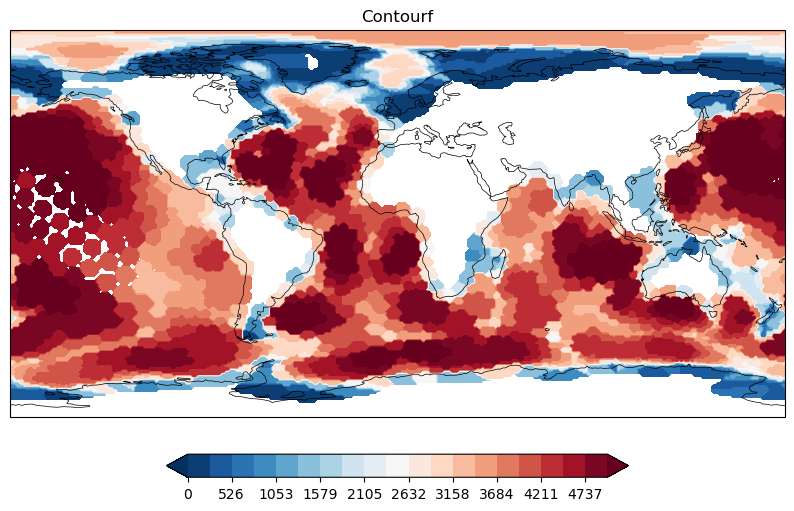

In [36]:
# Contourf (default) - smooth contours
fig, axes, _ = fesomp.plot(
    data, mesh.lon, mesh.lat,
    ptype='cf',  # contourf
    levels=(0, 5000, 20),  # min, max, number of levels
    titles='Contourf',
    interpolator=interp,
)
plt.show()

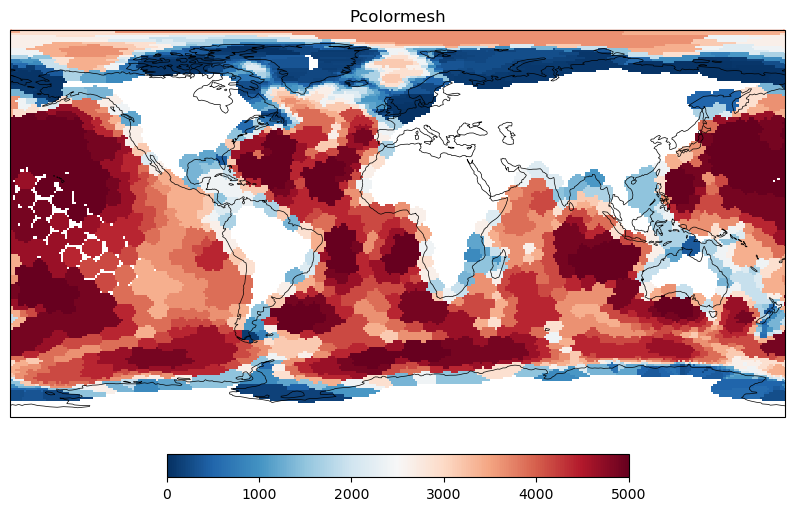

In [37]:
# Pcolormesh - shows grid cells
fig, axes, _ = fesomp.plot(
    data, mesh.lon, mesh.lat,
    ptype='pcm',  # pcolormesh
    levels=(0, 5000, 20),
    titles='Pcolormesh',
    interpolator=interp,
)
plt.show()

## 10. Working with xarray Data

Load FESOM output with xarray and plot directly.

In [ ]:
# Example: if you have FESOM output data
# import xarray as xr
# ds = xr.open_dataset('fesom_output.nc')
# 
# # Plot temperature at surface
# fig, axes, interp = fesomp.plot(
#     ds['temp'].isel(time=0, nz1=0).values,  # Extract numpy array
#     mesh.lon, mesh.lat,
#     cmap='RdBu_r',
#     units='°C',
#     titles='Sea Surface Temperature',
# )

print("Example code for xarray data (uncomment when you have FESOM output)")

## Summary

Key functions:

| Function | Purpose |
|----------|--------|
| `fesomp.plot()` | Quick visualization with map projection |
| `fesomp.regrid()` | Interpolate to regular grid |
| `fesomp.RegridInterpolator` | Cached interpolator for repeated use |

Key parameters:

| Parameter | Description | Default |
|-----------|-------------|--------|
| `box` | Region (lon_min, lon_max, lat_min, lat_max) | Global |
| `res` | Grid resolution (nlon, nlat) | (360, 180) |
| `influence` | Interpolation radius in meters | 80000 |
| `interp` | Method: 'nn', 'idw', 'linear' | 'nn' |
| `mapproj` | Projection: 'pc', 'rob', 'np', 'sp' | 'pc' |
| `rowscol` | Subplot layout (nrows, ncols) | (1, 1) |